---
title: "SVGP + RFF NN kernel"
---

# SVGP with a deep RFF kernel

The closing notebook in the pyrox SVGP trilogy. So far we've kept the kernel fixed (RBF) and varied the inducing distribution — point-inducing in [notebook 1](01_svgp_standard.ipynb), spherical-harmonic in [notebook 2](02_svgp_spherical_harmonics.ipynb). Now we keep the inducing distribution simple (point-inducing, $M = 30$) and replace the *kernel* with a deep-kernel construction.

The setup: a small MLP $\phi: \mathbb{R}^D \to \mathbb{R}^H$ warps the input space, and a **random-Fourier-feature** (RFF) projection of the warp produces a finite-dimensional kernel,

$$k(x, x') = \sigma^2 \, \psi(x)^\top \psi(x'), \qquad \psi(x) = \sqrt{\tfrac{2}{J}}\cos\!\bigl(W \phi(x) / \ell + b\bigr),$$

with $W \in \mathbb{R}^{H \times J}$ Gaussian, $b \in [0, 2\pi)^J$ uniform, and all of $\{\phi, W, b, \sigma, \ell\}$ trained jointly with the SVGP guide. The kernel is strictly PSD (it's an inner product of features) and has rank at most $J$, which is fine for $M \ll J$.

Pyrox ships nine different RFF families in [`pyrox.nn._layers`](https://github.com/jejjohnson/pyrox/blob/main/src/pyrox/nn/_layers.py) — RBF, Matérn, Laplace, arc-cosine, orthogonal, kitchen sinks, variational Fourier, HSGP — but for *this* notebook we hand-roll the RBF variant inside a custom `Kernel` subclass so the deep-kernel plumbing is fully explicit.

## Background — when does an RBF need help?

### The stationarity assumption

RBF kernels assume that the "right" notion of input similarity is Euclidean distance. Under one global lengthscale the prior covariance is the same function of $\|x - x'\|$ everywhere. That is a strong assumption — it fails whenever the generating process has direction-dependent or region-dependent smoothness.

### Two common failure modes

- **Anisotropy.** If the function is smooth in one direction and rough in another, a single $\ell$ smooths the rough direction too much or oscillates in the smooth one. ARD lengthscales fix this only when the principal axes align with the input axes.
- **Non-stationarity.** If the effective lengthscale varies across the input space — a high-frequency patch near the origin and a slowly varying tail far away — a single global $\ell$ cannot match both regimes simultaneously.

### Deep kernels, one sentence

An MLP is a universal function approximator; composing any stationary kernel with an MLP ($k(\phi(x), \phi(x'))$) gives a kernel that can be *non-stationary in the original input space* while remaining stationary in the warped space — exactly the inductive bias that the SVGP ELBO will push toward whatever warp best explains the data.

### Why RFF?

Two reasons. First, an RBF evaluated on a feature map has cost $\mathcal{O}(N M D)$ per training batch, where $D$ is the warp dimension; the RFF projection replaces that with $\mathcal{O}(N M J)$ where $J$ is a user-chosen truncation. Second, the features $\psi(x)$ are the *same* objects that SSGP and Bayesian-neural-field models expose — this notebook doubles as a bridge to pyrox's `pyrox.nn` RFF zoo.

## Setup

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import optax
from jaxtyping import Array, Float

from pyrox.gp import (
    GaussianLikelihood,
    Kernel,
    SparseGPPrior,
    WhitenedGuide,
    svgp_elbo,
)
from pyrox.gp._src.kernels import rbf_kernel

jax.config.update("jax_enable_x64", True)

/anaconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data — a warped 2D target

Target function $y(x_1, x_2) = \sin\!\bigl(2\pi (x_1^2 - x_2)\bigr)$ on $[-1, 1]^2$. The "effective" coordinate is the parabola $u = x_1^2 - x_2$, so level sets of the target are parabolic ridges. A stationary RBF can't represent the ridges cleanly with one lengthscale — the function looks highly oscillatory where $|x_1|$ is large and more gradual where $x_2$ dominates, a classic non-stationary pattern.

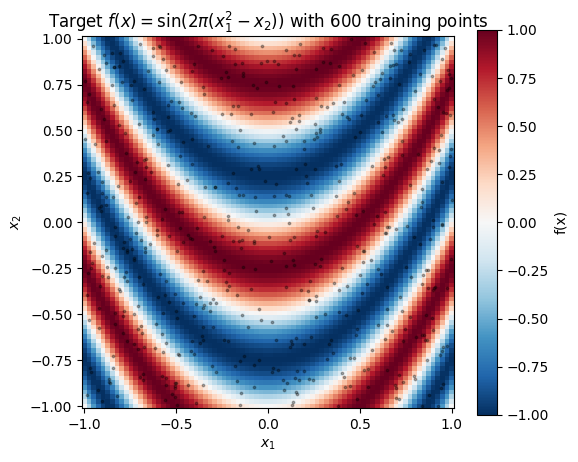

In [2]:
def f_true(X: Float[Array, "N 2"]) -> Float[Array, " N"]:
    return jnp.sin(2.0 * jnp.pi * (X[:, 0] ** 2 - X[:, 1]))


key = jr.PRNGKey(0)
key, key_X, key_noise = jr.split(key, 3)
N = 600
X_train = jr.uniform(key_X, (N, 2), minval=-1.0, maxval=1.0)
noise_std = 0.1
y_train = f_true(X_train) + noise_std * jr.normal(key_noise, (N,))

# Dense grid for plotting + evaluation.
G = 80
x1 = jnp.linspace(-1.0, 1.0, G)
x2 = jnp.linspace(-1.0, 1.0, G)
X1_grid, X2_grid = jnp.meshgrid(x1, x2, indexing="xy")
X_grid = jnp.stack([X1_grid.ravel(), X2_grid.ravel()], axis=-1)
y_grid_true = f_true(X_grid).reshape(G, G)

fig, ax = plt.subplots(figsize=(6, 5))
mesh = ax.pcolormesh(X1_grid, X2_grid, y_grid_true, cmap="RdBu_r", vmin=-1.0, vmax=1.0, shading="auto")
ax.scatter(X_train[:, 0], X_train[:, 1], s=3, alpha=0.3, color="k")
fig.colorbar(mesh, ax=ax, label="f(x)")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Target $f(x) = \\sin(2\\pi(x_1^2 - x_2))$ with 600 training points")
ax.set_aspect("equal")
plt.show()

Level sets of $f$ are the parabolas $x_1^2 - x_2 = c$ (plus any integer shift due to the $\sin$). A stationary RBF wants axis-aligned, constant-lengthscale isolines — the mismatch is severe.

## Kernels — RBF baseline and the deep RFF variant

In [3]:
class RBFLite(Kernel, eqx.Module):
    """Pure-equinox RBF — the baseline from notebooks 1 and 2."""

    log_variance: Float[Array, ""]
    log_lengthscale: Float[Array, ""]

    @classmethod
    def init(cls, variance: float = 1.0, lengthscale: float = 1.0) -> "RBFLite":
        return cls(
            log_variance=jnp.log(jnp.asarray(variance)),
            log_lengthscale=jnp.log(jnp.asarray(lengthscale)),
        )

    @property
    def variance(self) -> Float[Array, ""]:
        return jnp.exp(self.log_variance)

    @property
    def lengthscale(self) -> Float[Array, ""]:
        return jnp.exp(self.log_lengthscale)

    def __call__(
        self,
        X1: Float[Array, "N1 D"],
        X2: Float[Array, "N2 D"],
    ) -> Float[Array, "N1 N2"]:
        return rbf_kernel(X1, X2, self.variance, self.lengthscale)

    def diag(self, X: Float[Array, "N D"]) -> Float[Array, " N"]:
        return self.variance * jnp.ones(X.shape[0], dtype=X.dtype)

The deep RFF kernel carries trainable `mlp`, `W`, `b`, and log-scales. The MLP is a plain `equinox.nn.MLP` (two hidden layers, 32 units, `tanh` activation); its parameters are equinox leaves and train via the same `optax.adam` loop as the other scalars.

In [4]:
class DeepRFFKernel(Kernel, eqx.Module):
    """Deep kernel:  k(x, x') = σ² ⟨ψ(x), ψ(x')⟩  where  ψ = RFF ∘ MLP."""

    mlp: eqx.nn.MLP
    W: Float[Array, "H J"]
    b: Float[Array, " J"]
    log_variance: Float[Array, ""]
    log_feature_lengthscale: Float[Array, ""]

    @classmethod
    def init(
        cls,
        in_dim: int,
        hidden_dim: int,
        num_features: int,
        *,
        key: jr.PRNGKey,
        mlp_width: int = 32,
        mlp_depth: int = 2,
        variance: float = 1.0,
        feature_lengthscale: float = 1.0,
    ) -> "DeepRFFKernel":
        k_mlp, k_W, k_b = jr.split(key, 3)
        mlp = eqx.nn.MLP(
            in_size=in_dim,
            out_size=hidden_dim,
            width_size=mlp_width,
            depth=mlp_depth,
            activation=jax.nn.tanh,
            key=k_mlp,
        )
        W = jr.normal(k_W, (hidden_dim, num_features))
        b = jr.uniform(k_b, (num_features,)) * 2.0 * jnp.pi
        return cls(
            mlp=mlp,
            W=W,
            b=b,
            log_variance=jnp.log(jnp.asarray(variance)),
            log_feature_lengthscale=jnp.log(jnp.asarray(feature_lengthscale)),
        )

    def _features(self, X: Float[Array, "N D"]) -> Float[Array, "N J"]:
        phi = jax.vmap(self.mlp)(X)
        z = phi @ self.W / jnp.exp(self.log_feature_lengthscale) + self.b
        return jnp.sqrt(2.0 / self.W.shape[1]) * jnp.cos(z)

    def __call__(
        self,
        X1: Float[Array, "N1 D"],
        X2: Float[Array, "N2 D"],
    ) -> Float[Array, "N1 N2"]:
        return jnp.exp(self.log_variance) * self._features(X1) @ self._features(X2).T

    def diag(self, X: Float[Array, "N D"]) -> Float[Array, " N"]:
        psi = self._features(X)
        return jnp.exp(self.log_variance) * jnp.sum(psi * psi, axis=-1)


class TrainableGaussianLikelihood(eqx.Module):
    log_noise_var: Float[Array, ""]

    @classmethod
    def init(cls, noise_var: float = 0.1) -> "TrainableGaussianLikelihood":
        return cls(log_noise_var=jnp.log(jnp.asarray(noise_var)))

    def materialise(self) -> GaussianLikelihood:
        return GaussianLikelihood(noise_var=jnp.exp(self.log_noise_var))

## Shared training loop

Same ELBO, same optimiser — only the kernel inside `prior` changes between the two runs.

In [5]:
Params = tuple


def neg_elbo(params: Params, X: Float[Array, "N D"], y: Float[Array, " N"]) -> Float[Array, ""]:
    prior_p, guide_p, lik_p = params
    return -svgp_elbo(prior_p, guide_p, lik_p.materialise(), X, y)


def train(
    prior: SparseGPPrior,
    guide: WhitenedGuide,
    lik_w: TrainableGaussianLikelihood,
    X: Float[Array, "N D"],
    y: Float[Array, " N"],
    *,
    lr: float = 1e-2,
    n_steps: int = 3000,
) -> tuple[Params, list[float]]:
    params = (prior, guide, lik_w)
    # Gradient clipping keeps the deep-kernel loss smooth — without it, Adam
    # occasionally lands a step that pushes the MLP into a flat region of the
    # cos-feature map and the ELBO spikes before recovering.
    optimiser = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(lr))
    opt_state = optimiser.init(eqx.filter(params, eqx.is_inexact_array))

    @eqx.filter_jit
    def step(params, opt_state):
        loss, grads = eqx.filter_value_and_grad(neg_elbo)(params, X, y)
        updates, opt_state = optimiser.update(grads, opt_state, params)
        return eqx.apply_updates(params, updates), opt_state, loss

    losses: list[float] = []
    for _ in range(n_steps):
        params, opt_state, loss = step(params, opt_state)
        losses.append(float(loss))
    return params, losses

## Baseline — standard SVGP with RBF kernel

$M = 30$ inducing points on a $6 \times 5$ grid covering the domain.

In [6]:
M = 30
gx, gy = jnp.meshgrid(jnp.linspace(-0.8, 0.8, 6), jnp.linspace(-0.8, 0.8, 5), indexing="xy")
Z_init = jnp.stack([gx.ravel(), gy.ravel()], axis=-1)

prior_rbf = SparseGPPrior(
    kernel=RBFLite.init(variance=1.0, lengthscale=0.3),
    Z=Z_init,
    jitter=1e-4,
)
guide_rbf = WhitenedGuide.init(num_inducing=M)
lik_rbf = TrainableGaussianLikelihood.init(noise_var=noise_std**2)

(prior_rbf_fit, guide_rbf_fit, lik_rbf_fit), losses_rbf = train(
    prior_rbf, guide_rbf, lik_rbf, X_train, y_train
)
print(f"RBF     final -ELBO = {losses_rbf[-1]:.3f}")
print(f"        variance    = {float(prior_rbf_fit.kernel.variance):.3f}")
print(f"        lengthscale = {float(prior_rbf_fit.kernel.lengthscale):.3f}")
print(f"        noise std   = {float(jnp.exp(0.5 * lik_rbf_fit.log_noise_var)):.3f}  (truth {noise_std})")

RBF     final -ELBO = 283.729
        variance    = 0.215
        lengthscale = 0.250
        noise std   = 0.293  (truth 0.1)


## Deep RFF — same scaffold, swapped kernel

$J = 256$ Fourier features, hidden width 8 in the MLP output, initial feature lengthscale 0.5. Deep kernels have a noticeably harder loss landscape than the RBF baseline (more parameters, trigonometric nonlinearity in the features), so we drop the learning rate to `1e-2` and train for `3000` steps. With the stock `5e-2 / 1200` settings the MLP doesn't have time to learn a useful warp and the deep kernel ends up *worse* than the RBF — a reminder that expressive priors are only useful when the optimiser can reach them.

In [7]:
prior_deep = SparseGPPrior(
    kernel=DeepRFFKernel.init(
        in_dim=2,
        hidden_dim=8,
        num_features=256,
        key=jr.PRNGKey(7),
        mlp_width=32,
        mlp_depth=2,
        variance=1.0,
        feature_lengthscale=0.5,
    ),
    Z=Z_init,
    jitter=1e-4,
)
guide_deep = WhitenedGuide.init(num_inducing=M)
lik_deep = TrainableGaussianLikelihood.init(noise_var=noise_std**2)

(prior_deep_fit, guide_deep_fit, lik_deep_fit), losses_deep = train(
    prior_deep, guide_deep, lik_deep, X_train, y_train
)
print(f"DeepRFF final -ELBO = {losses_deep[-1]:.3f}")
print(f"        variance    = {float(jnp.exp(prior_deep_fit.kernel.log_variance)):.3f}")
print(f"        feat scale  = {float(jnp.exp(prior_deep_fit.kernel.log_feature_lengthscale)):.3f}")
print(f"        noise std   = {float(jnp.exp(0.5 * lik_deep_fit.log_noise_var)):.3f}  (truth {noise_std})")

DeepRFF final -ELBO = -493.297
        variance    = 0.444
        feat scale  = 0.843
        noise std   = 0.101  (truth 0.1)


### Loss curves — side by side

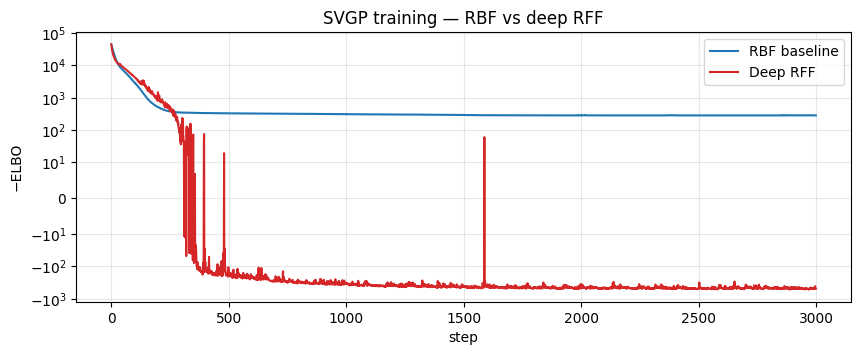

In [8]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(losses_rbf, color="C0", lw=1.5, label="RBF baseline")
ax.plot(losses_deep, color="C3", lw=1.5, label="Deep RFF")
ax.set_xlabel("step")
ax.set_ylabel("−ELBO")
ax.set_yscale("symlog", linthresh=10.0)
ax.set_title("SVGP training — RBF vs deep RFF")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.show()

## Posterior comparison

Evaluate both posteriors on the $80 \times 80$ grid and plot mean + |mean − truth| error maps side-by-side.

grid RMSE (RBF)     = 0.234
grid RMSE (DeepRFF) = 0.037
noise-std baseline  = 0.100  (a perfect model would roughly match this)


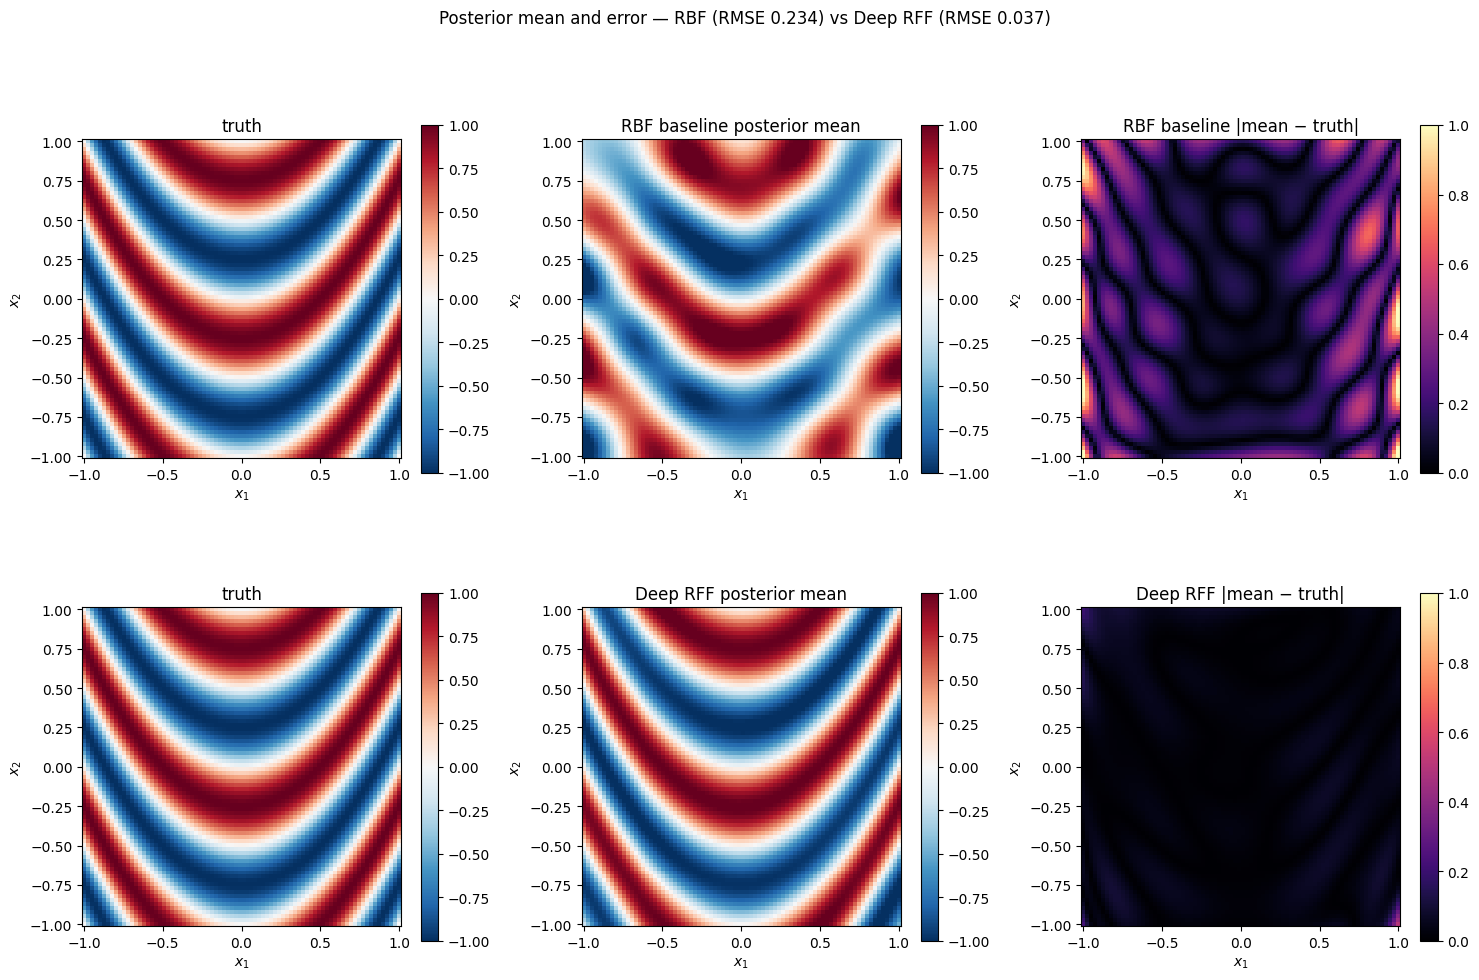

In [9]:
def posterior_mean(prior_fit, guide_fit, X_eval):
    K_zz_op, K_xz, K_xx_diag = prior_fit.predictive_blocks(X_eval)
    f_loc, _ = guide_fit.predict(K_xz, K_zz_op, K_xx_diag)
    return (f_loc + prior_fit.mean(X_eval)).reshape(G, G)


mean_rbf = posterior_mean(prior_rbf_fit, guide_rbf_fit, X_grid)
mean_deep = posterior_mean(prior_deep_fit, guide_deep_fit, X_grid)
err_rbf = jnp.abs(mean_rbf - y_grid_true)
err_deep = jnp.abs(mean_deep - y_grid_true)

rmse_rbf = float(jnp.sqrt(jnp.mean((mean_rbf - y_grid_true) ** 2)))
rmse_deep = float(jnp.sqrt(jnp.mean((mean_deep - y_grid_true) ** 2)))
print(f"grid RMSE (RBF)     = {rmse_rbf:.3f}")
print(f"grid RMSE (DeepRFF) = {rmse_deep:.3f}")
print(f"noise-std baseline  = {noise_std:.3f}  (a perfect model would roughly match this)")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for row, (name, mean_pred, err) in enumerate([
    ("RBF baseline", mean_rbf, err_rbf),
    ("Deep RFF", mean_deep, err_deep),
]):
    for col, (field, title, vmin, vmax, cmap) in enumerate([
        (y_grid_true, "truth", -1.0, 1.0, "RdBu_r"),
        (mean_pred, f"{name} posterior mean", -1.0, 1.0, "RdBu_r"),
        (err, f"{name} |mean − truth|", 0.0, 1.0, "magma"),
    ]):
        ax = axes[row, col]
        mesh = ax.pcolormesh(X1_grid, X2_grid, field, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
        fig.colorbar(mesh, ax=ax, shrink=0.75)
        ax.set_aspect("equal")
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
        ax.set_title(title)
fig.suptitle(f"Posterior mean and error — RBF (RMSE {rmse_rbf:.3f}) vs Deep RFF (RMSE {rmse_deep:.3f})", y=1.01)
plt.tight_layout()
plt.show()

### The learned warp

What does the MLP *do* to the input space? Pass a uniform $x$-grid through `kernel.mlp` and scatter the result — this is the geometry the downstream RFF layer actually sees. A pair of adjacent test points whose true targets differ should be pushed apart by the warp; a pair with similar targets should be pulled together.

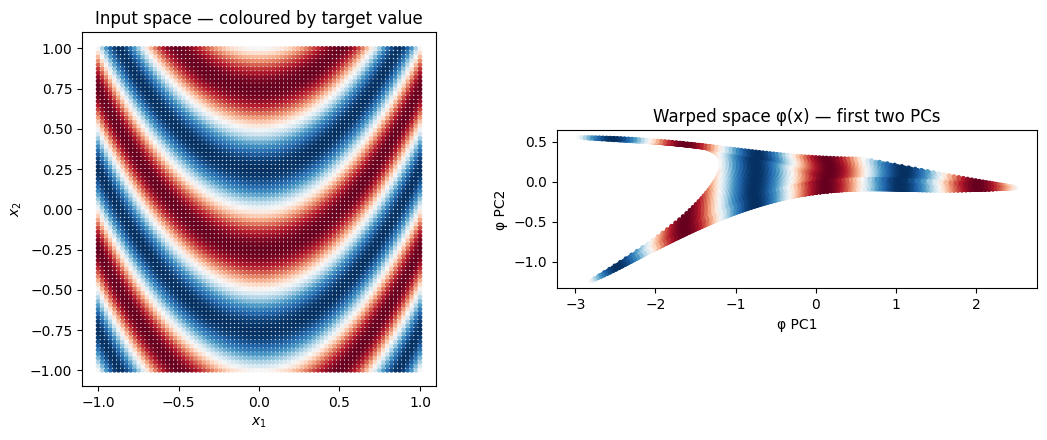

In [10]:
phi_grid = jax.vmap(prior_deep_fit.kernel.mlp)(X_grid)

# Colour each warped point by its true target value, so the visual is
# "similar colours cluster" iff the warp has learned the right metric.
target_colour = y_grid_true.ravel()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(
    X_grid[:, 0],
    X_grid[:, 1],
    c=target_colour,
    cmap="RdBu_r",
    vmin=-1.0,
    vmax=1.0,
    s=6,
)
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].set_title("Input space — coloured by target value")
axes[0].set_aspect("equal")

# Show the first two principal axes of phi(X_grid) — this is the 4-dim
# warp projected to 2D for visualisation only.
phi_centred = phi_grid - phi_grid.mean(axis=0, keepdims=True)
_, _, Vt = jnp.linalg.svd(phi_centred, full_matrices=False)
phi_2d = phi_centred @ Vt[:2].T
axes[1].scatter(
    phi_2d[:, 0],
    phi_2d[:, 1],
    c=target_colour,
    cmap="RdBu_r",
    vmin=-1.0,
    vmax=1.0,
    s=6,
)
axes[1].set_xlabel("φ PC1")
axes[1].set_ylabel("φ PC2")
axes[1].set_title("Warped space φ(x) — first two PCs")
axes[1].set_aspect("equal")
plt.tight_layout()
plt.show()

In the left panel, neighbouring points can have wildly different colours — the parabolic level sets of the target tangle any local Euclidean metric. In the right panel the warp should re-layer those same points so that *colour correlates with position*: same-coloured points cluster, gradients become smooth. That is the geometry the SVGP kernel now operates on, and it is the reason the deep-RFF posterior mean matches the truth where the RBF's one-lengthscale smoother cannot.

## Summary

- Three SVGPs, one ELBO, one training loop — only the kernel changes between notebooks. Point-inducing RBF (notebook 1), spherical-harmonic inducing (notebook 2), deep RFF kernel (this notebook).
- Deep kernels buy expressive power when the input geometry is non-stationary, at the cost of more parameters and a harder loss landscape — watch for overfitting, especially with small $N$.
- The RFF projection keeps the kernel matrix low-rank ($J$ features) while the MLP does the heavy lifting; bumping $J$ and hidden width independently gives two orthogonal dials for capacity.

**Where to go next.** Pyrox ships eight other RFF variants in `pyrox.nn._layers` (Matérn RFF, Laplace RFF, arc-cosine features, orthogonal random features, kitchen sinks, HSGP features, variational Fourier features) — each is a drop-in replacement for the `cos(Wx + b)` basis used above. The [`pyrox.gp.FourierInducingFeatures`](https://github.com/jejjohnson/pyrox/blob/main/src/pyrox/gp/_inducing.py) family lets you combine a deep kernel with inter-domain inducing features for the best-of-both-worlds recipe on bounded domains; pair with `NaturalGuide` + `ConjugateVI` for natural-gradient training, or with `DistLikelihood` for Bernoulli/Poisson SVGPs.